In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "/Users/arnarfreyrerlingsson/Desktop/Polymarket_bitcoin_5min/db/polymarket.duckdb"

In [2]:
def query_to_df(query, limit=1000):
    if limit:
        limit = f"\n LIMIT {limit}"
    else:
        limit = ""

    con = duckdb.connect(DB_PATH,read_only=True)
    try:
        query = str(query) + limit
        df = con.execute(query).df()
        return df
    finally:
        con.close()

In [3]:
query = """
SHOW TABLES
"""
query_to_df(query,None)

,name
0,MARKET_TRADES
1,bitcoin_prices
2,btc_history
3,btc_summary
4,btc_trades


In [14]:
query = """ SELECT * FROM bitcoin_prices"""
#query_to_df(query,100)

In [18]:
query = """
SELECT OPEN_TIME AS THE_TIME,OPEN AS PRICE,VOLUME,QUOTE_VOLUME,COUNT,TAKER_BUY_VOLUME,TAKER_BUY_QUOTE_VOLUME,IGNORE
FROM bitcoin_prices
    WHERE OPEN_TIME BETWEEN TIMESTAMPTZ '2026-06-10 12:30:00+00:00' AND TIMESTAMPTZ '2026-06-10 12:36:00+00:00'
    ORDER BY OPEN_TIME ASC
"""
df = query_to_df(query,1000000)


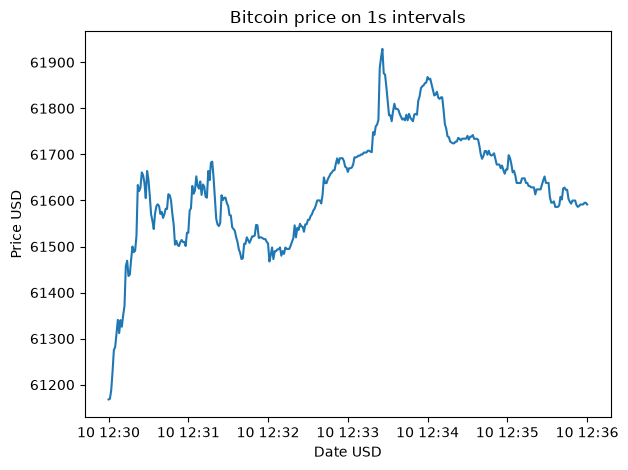

In [19]:
plt.plot(df['THE_TIME'],df['PRICE'])
plt.ylabel("Price USD")
plt.xlabel("Date USD")
plt.title("Bitcoin price on 1s intervals")
plt.tight_layout()
plt.show()